STEP 1 — Load & Audit the Raw Dataset


In [1]:
import pandas as pd

# Load the raw dataset
df = pd.read_csv("retail_store_sales.csv")

# Basic dataset overview
print("Dataset Shape:", df.shape)
print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nFirst 5 Rows:")
display(df.head())

Dataset Shape: (12575, 11)

Column Names:
['Transaction ID', 'Customer ID', 'Category', 'Item', 'Price Per Unit', 'Quantity', 'Total Spent', 'Payment Method', 'Location', 'Transaction Date', 'Discount Applied']

Data Types:
Transaction ID       object
Customer ID          object
Category             object
Item                 object
Price Per Unit      float64
Quantity            float64
Total Spent         float64
Payment Method       object
Location             object
Transaction Date     object
Discount Applied     object
dtype: object

First 5 Rows:


,Transaction ID,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied
0,TXN_6867343,CUST_09,Patisserie,Item_10_PAT,18.5,10.0,185.0,Digital Wallet,Online,2024-04-08,True
1,TXN_3731986,CUST_22,Milk Products,Item_17_MILK,29.0,9.0,261.0,Digital Wallet,Online,2023-07-23,True
2,TXN_9303719,CUST_02,Butchers,Item_12_BUT,21.5,2.0,43.0,Credit Card,Online,2022-10-05,False
3,TXN_9458126,CUST_06,Beverages,Item_16_BEV,27.5,9.0,247.5,Credit Card,Online,2022-05-07,NaN
4,TXN_4575373,CUST_05,Food,Item_6_FOOD,12.5,7.0,87.5,Digital Wallet,Online,2022-10-02,False


In [2]:
# STEP 2: Complete Data Quality Audit

print("=" * 60)
print("DATA QUALITY AUDIT")
print("=" * 60)

# 1. Missing values
print("\n1. MISSING VALUES")
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

missing_report = pd.DataFrame({
    "Missing Count": missing,
    "Missing %": missing_pct
})

display(missing_report[missing_report["Missing Count"] > 0]
        .sort_values("Missing Count", ascending=False))


# 2. Duplicate rows
print("\n2. DUPLICATE ROWS")
duplicate_count = df.duplicated().sum()
print("Duplicate rows:", duplicate_count)


# 3. Unique values in categorical columns
print("\n3. CATEGORICAL VALUE CHECK")

categorical_cols = df.select_dtypes(include="object").columns

for col in categorical_cols:
    print(f"\n{col}")
    print("Unique values:", df[col].nunique(dropna=True))
    print(df[col].dropna().value_counts().head(10))


# 4. Numeric summary
print("\n4. NUMERIC SUMMARY")

numeric_cols = df.select_dtypes(include="number").columns

display(df[numeric_cols].describe().T)


# 5. Basic validation checks
print("\n5. BASIC VALIDATION")

print("Negative Price Per Unit:",
      (df["Price Per Unit"] < 0).sum())

print("Negative Quantity:",
      (df["Quantity"] < 0).sum())

print("Negative Total Spent:",
      (df["Total Spent"] < 0).sum())


# 6. Dataset memory and completeness
print("\n6. DATASET COMPLETENESS")

total_cells = df.shape[0] * df.shape[1]
missing_cells = df.isnull().sum().sum()

print("Total cells:", total_cells)
print("Missing cells:", missing_cells)
print("Completeness:",
      round((1 - missing_cells / total_cells) * 100, 2), "%")

DATA QUALITY AUDIT

1. MISSING VALUES


,Missing Count,Missing %
Discount Applied,4199,33.39
Item,1213,9.65
Price Per Unit,609,4.84
Quantity,604,4.80
Total Spent,604,4.80



2. DUPLICATE ROWS
Duplicate rows: 0

3. CATEGORICAL VALUE CHECK

Transaction ID
Unique values: 12575
Transaction ID
TXN_2407494    1
TXN_6867343    1
TXN_3731986    1
TXN_9303719    1
TXN_9458126    1
TXN_4575373    1
TXN_7482416    1
TXN_3652209    1
TXN_1372952    1
TXN_9728486    1
Name: count, dtype: int64

Customer ID
Unique values: 25
Customer ID
CUST_05    544
CUST_24    543
CUST_13    534
CUST_08    533
CUST_09    519
CUST_15    519
CUST_16    515
CUST_23    513
CUST_20    507
CUST_18    507
Name: count, dtype: int64

Category
Unique values: 8
Category
Electric household essentials         1591
Furniture                             1591
Food                                  1588
Milk Products                         1584
Butchers                              1568
Beverages                             1567
Computers and electric accessories    1558
Patisserie                            1528
Name: count, dtype: int64

Item
Unique values: 200
Item
Item_2_BEV      126
Item_25_FUR 

,count,mean,std,min,25%,50%,75%,max
Price Per Unit,11966.0,23.365912,10.743519,5.0,14.0,23.0,33.5,41.0
Quantity,11971.0,5.536380,2.857883,1.0,3.0,6.0,8.0,10.0
Total Spent,11971.0,129.652577,94.750697,5.0,51.0,108.5,192.0,410.0



5. BASIC VALIDATION
Negative Price Per Unit: 0
Negative Quantity: 0
Negative Total Spent: 0

6. DATASET COMPLETENESS
Total cells: 138325
Missing cells: 7229
Completeness: 94.77 %


In [3]:
# STEP 3: Consistency & Relationship Audit

print("=" * 60)
print("CONSISTENCY & RELATIONSHIP AUDIT")
print("=" * 60)


# --------------------------------------------------
# 1. Missing-value combinations
# --------------------------------------------------

print("\n1. MISSING VALUE PATTERNS")

important_cols = [
    "Item",
    "Price Per Unit",
    "Quantity",
    "Total Spent",
    "Discount Applied"
]

missing_pattern = (
    df[important_cols]
    .isnull()
    .value_counts()
    .reset_index(name="Row Count")
)

display(missing_pattern)


# --------------------------------------------------
# 2. Can Total Spent be calculated from Price × Quantity?
# --------------------------------------------------

print("\n2. TOTAL SPENT CONSISTENCY")

complete_amount = df[
    df["Price Per Unit"].notna() &
    df["Quantity"].notna() &
    df["Total Spent"].notna()
].copy()

complete_amount["Calculated Total"] = (
    complete_amount["Price Per Unit"] *
    complete_amount["Quantity"]
)

complete_amount["Difference"] = (
    complete_amount["Total Spent"] -
    complete_amount["Calculated Total"]
).abs()

print("Rows with all 3 financial fields:", len(complete_amount))

print(
    "Rows where Total Spent differs from Price × Quantity:",
    (complete_amount["Difference"] > 0.01).sum()
)

print(
    "Maximum difference:",
    round(complete_amount["Difference"].max(), 2)
)


# --------------------------------------------------
# 3. Category vs Item consistency
# --------------------------------------------------

print("\n3. CATEGORY / ITEM CONSISTENCY")

item_category_counts = (
    df.dropna(subset=["Item", "Category"])
      .groupby("Item")["Category"]
      .nunique()
)

inconsistent_items = item_category_counts[
    item_category_counts > 1
]

print(
    "Items appearing in multiple categories:",
    len(inconsistent_items)
)

if len(inconsistent_items) > 0:
    display(
        df[df["Item"].isin(inconsistent_items.index)]
        [["Item", "Category"]]
        .drop_duplicates()
        .sort_values("Item")
        .head(30)
    )


# --------------------------------------------------
# 4. Transaction ID uniqueness
# --------------------------------------------------

print("\n4. TRANSACTION ID CHECK")

print(
    "Unique Transaction IDs:",
    df["Transaction ID"].nunique()
)

print(
    "Total rows:",
    len(df)
)

print(
    "Duplicate Transaction IDs:",
    df["Transaction ID"].duplicated().sum()
)


# --------------------------------------------------
# 5. Customer ID validation
# --------------------------------------------------

print("\n5. CUSTOMER ID CHECK")

print(
    "Unique Customer IDs:",
    df["Customer ID"].nunique()
)

print(
    "Missing Customer IDs:",
    df["Customer ID"].isna().sum()
)


# --------------------------------------------------
# 6. Date validation
# --------------------------------------------------

print("\n6. DATE VALIDATION")

parsed_dates = pd.to_datetime(
    df["Transaction Date"],
    errors="coerce"
)

print(
    "Valid dates:",
    parsed_dates.notna().sum()
)

print(
    "Invalid dates:",
    parsed_dates.isna().sum()
)

if parsed_dates.notna().any():
    print(
        "Date range:",
        parsed_dates.min().date(),
        "to",
        parsed_dates.max().date()
    )


# --------------------------------------------------
# 7. Text consistency check
# --------------------------------------------------

print("\n7. TEXT CONSISTENCY CHECK")

text_columns = [
    "Category",
    "Payment Method",
    "Location",
    "Discount Applied"
]

for col in text_columns:
    values = (
        df[col]
        .dropna()
        .astype(str)
        .str.strip()
    )

    print(f"\n{col}")
    print("Unique values:", values.nunique())
    print("Values:", sorted(values.unique())[:30])

CONSISTENCY & RELATIONSHIP AUDIT

1. MISSING VALUE PATTERNS


,Item,Price Per Unit,Quantity,Total Spent,Discount Applied,Row Count
0,False,False,False,False,False,7579
1,False,False,False,False,True,3783
2,True,True,False,False,False,404
3,True,False,True,True,False,393
4,True,False,True,True,True,211
5,True,True,False,False,True,205



2. TOTAL SPENT CONSISTENCY
Rows with all 3 financial fields: 11362
Rows where Total Spent differs from Price × Quantity: 0
Maximum difference: 0.0

3. CATEGORY / ITEM CONSISTENCY
Items appearing in multiple categories: 0

4. TRANSACTION ID CHECK
Unique Transaction IDs: 12575
Total rows: 12575
Duplicate Transaction IDs: 0

5. CUSTOMER ID CHECK
Unique Customer IDs: 25
Missing Customer IDs: 0

6. DATE VALIDATION
Valid dates: 12575
Invalid dates: 0
Date range: 2022-01-01 to 2025-01-18

7. TEXT CONSISTENCY CHECK

Category
Unique values: 8
Values: ['Beverages', 'Butchers', 'Computers and electric accessories', 'Electric household essentials', 'Food', 'Furniture', 'Milk Products', 'Patisserie']

Payment Method
Unique values: 3
Values: ['Cash', 'Credit Card', 'Digital Wallet']

Location
Unique values: 2
Values: ['In-store', 'Online']

Discount Applied
Unique values: 2
Values: ['False', 'True']


In [4]:
# STEP 4: Create a reproducible cleaning pipeline

import numpy as np

# Keep the raw dataset untouched
clean_df = df.copy()

print("Starting rows:", len(clean_df))


# --------------------------------------------------
# 1. Standardize text fields
# --------------------------------------------------

text_columns = [
    "Transaction ID",
    "Customer ID",
    "Category",
    "Item",
    "Payment Method",
    "Location"
]

for col in text_columns:
    clean_df[col] = clean_df[col].astype("string").str.strip()


# --------------------------------------------------
# 2. Convert Transaction Date to datetime
# --------------------------------------------------

clean_df["Transaction Date"] = pd.to_datetime(
    clean_df["Transaction Date"],
    errors="coerce"
)


# --------------------------------------------------
# 3. Standardize Discount Applied
# --------------------------------------------------

# Preserve missing discount information as "Unknown"
clean_df["Discount Applied"] = (
    clean_df["Discount Applied"]
    .astype("string")
    .str.strip()
    .fillna("Unknown")
)


# --------------------------------------------------
# 4. Handle missing Item values
# --------------------------------------------------

clean_df["Item"] = (
    clean_df["Item"]
    .fillna("Unknown Item")
)


# --------------------------------------------------
# 5. Recover missing Price Per Unit
# --------------------------------------------------

price_recoverable = (
    clean_df["Price Per Unit"].isna()
    & clean_df["Quantity"].notna()
    & clean_df["Total Spent"].notna()
    & (clean_df["Quantity"] != 0)
)

clean_df.loc[price_recoverable, "Price Per Unit"] = (
    clean_df.loc[price_recoverable, "Total Spent"]
    / clean_df.loc[price_recoverable, "Quantity"]
)

print(
    "Price values recovered:",
    price_recoverable.sum()
)


# --------------------------------------------------
# 6. Fill missing Quantity using category median
# --------------------------------------------------

category_quantity_median = (
    clean_df
    .groupby("Category")["Quantity"]
    .transform("median")
)

quantity_missing = clean_df["Quantity"].isna()

clean_df.loc[quantity_missing, "Quantity"] = (
    category_quantity_median[quantity_missing]
)

print(
    "Quantity values imputed:",
    quantity_missing.sum()
)


# --------------------------------------------------
# 7. Recalculate missing Total Spent
# --------------------------------------------------

total_missing = clean_df["Total Spent"].isna()

clean_df.loc[total_missing, "Total Spent"] = (
    clean_df.loc[total_missing, "Price Per Unit"]
    * clean_df.loc[total_missing, "Quantity"]
)

print(
    "Total Spent values calculated:",
    total_missing.sum()
)


# --------------------------------------------------
# 8. Convert numeric columns explicitly
# --------------------------------------------------

numeric_columns = [
    "Price Per Unit",
    "Quantity",
    "Total Spent"
]

for col in numeric_columns:
    clean_df[col] = pd.to_numeric(
        clean_df[col],
        errors="coerce"
    )


# --------------------------------------------------
# 9. Final ordering
# --------------------------------------------------

clean_df = clean_df[
    [
        "Transaction ID",
        "Customer ID",
        "Category",
        "Item",
        "Price Per Unit",
        "Quantity",
        "Total Spent",
        "Payment Method",
        "Location",
        "Transaction Date",
        "Discount Applied"
    ]
]


print("\nCleaning pipeline completed.")
print("Final rows:", len(clean_df))
print("Final columns:", len(clean_df.columns))

Starting rows: 12575
Price values recovered: 609
Quantity values imputed: 604
Total Spent values calculated: 604

Cleaning pipeline completed.
Final rows: 12575
Final columns: 11


In [5]:
# STEP 5: Post-Cleaning Validation

print("=" * 60)
print("POST-CLEANING DATA QUALITY VALIDATION")
print("=" * 60)


# --------------------------------------------------
# 1. Missing values after cleaning
# --------------------------------------------------

print("\n1. MISSING VALUES AFTER CLEANING")

remaining_missing = clean_df.isnull().sum()

missing_after = pd.DataFrame({
    "Missing Count": remaining_missing,
    "Missing %": (remaining_missing / len(clean_df) * 100).round(2)
})

display(
    missing_after[missing_after["Missing Count"] > 0]
)


# --------------------------------------------------
# 2. Duplicate validation
# --------------------------------------------------

print("\n2. DUPLICATE VALIDATION")

print(
    "Duplicate rows:",
    clean_df.duplicated().sum()
)

print(
    "Duplicate Transaction IDs:",
    clean_df["Transaction ID"].duplicated().sum()
)


# --------------------------------------------------
# 3. Financial consistency
# --------------------------------------------------

print("\n3. FINANCIAL CONSISTENCY")

clean_df["Expected Total"] = (
    clean_df["Price Per Unit"] *
    clean_df["Quantity"]
)

clean_df["Amount Difference"] = (
    clean_df["Total Spent"] -
    clean_df["Expected Total"]
).abs()

financial_errors = (
    clean_df["Amount Difference"] > 0.01
).sum()

print(
    "Financial inconsistencies:",
    financial_errors
)

print(
    "Maximum financial difference:",
    round(clean_df["Amount Difference"].max(), 2)
)


# --------------------------------------------------
# 4. Numeric validation
# --------------------------------------------------

print("\n4. NUMERIC VALIDATION")

print(
    "Missing Price:",
    clean_df["Price Per Unit"].isna().sum()
)

print(
    "Missing Quantity:",
    clean_df["Quantity"].isna().sum()
)

print(
    "Missing Total Spent:",
    clean_df["Total Spent"].isna().sum()
)

print(
    "Negative Price:",
    (clean_df["Price Per Unit"] < 0).sum()
)

print(
    "Negative Quantity:",
    (clean_df["Quantity"] < 0).sum()
)

print(
    "Negative Total Spent:",
    (clean_df["Total Spent"] < 0).sum()
)


# --------------------------------------------------
# 5. Date validation
# --------------------------------------------------

print("\n5. DATE VALIDATION")

print(
    "Invalid dates:",
    clean_df["Transaction Date"].isna().sum()
)

print(
    "Minimum date:",
    clean_df["Transaction Date"].min()
)

print(
    "Maximum date:",
    clean_df["Transaction Date"].max()
)


# --------------------------------------------------
# 6. Categorical validation
# --------------------------------------------------

print("\n6. CATEGORICAL VALIDATION")

print(
    "Discount values:",
    clean_df["Discount Applied"].value_counts(dropna=False).to_dict()
)

print(
    "Unknown Items:",
    (clean_df["Item"] == "Unknown Item").sum()
)


# --------------------------------------------------
# 7. Remove temporary validation columns
# --------------------------------------------------

clean_df.drop(
    columns=["Expected Total", "Amount Difference"],
    inplace=True
)


# --------------------------------------------------
# FINAL STATUS
# --------------------------------------------------

print("\n" + "=" * 60)
print("VALIDATION COMPLETE")
print("=" * 60)

POST-CLEANING DATA QUALITY VALIDATION

1. MISSING VALUES AFTER CLEANING


,Missing Count,Missing %



2. DUPLICATE VALIDATION
Duplicate rows: 0
Duplicate Transaction IDs: 0

3. FINANCIAL CONSISTENCY
Financial inconsistencies: 0
Maximum financial difference: 0.0

4. NUMERIC VALIDATION
Missing Price: 0
Missing Quantity: 0
Missing Total Spent: 0
Negative Price: 0
Negative Quantity: 0
Negative Total Spent: 0

5. DATE VALIDATION
Invalid dates: 0
Minimum date: 2022-01-01 00:00:00
Maximum date: 2025-01-18 00:00:00

6. CATEGORICAL VALIDATION
Discount values: {'True': 4219, 'Unknown': 4199, 'False': 4157}
Unknown Items: 1213

VALIDATION COMPLETE


In [6]:
# STEP 6: Before vs After Data Quality Report

print("=" * 70)
print("BEFORE vs AFTER DATA QUALITY REPORT")
print("=" * 70)


# --------------------------------------------------
# 1. Calculate raw-data quality metrics
# --------------------------------------------------

raw_missing_cells = df.isnull().sum().sum()
raw_total_cells = df.shape[0] * df.shape[1]

raw_completeness = (
    (1 - raw_missing_cells / raw_total_cells) * 100
)


# --------------------------------------------------
# 2. Calculate cleaned-data quality metrics
# --------------------------------------------------

clean_missing_cells = clean_df.isnull().sum().sum()
clean_total_cells = clean_df.shape[0] * clean_df.shape[1]

clean_completeness = (
    (1 - clean_missing_cells / clean_total_cells) * 100
)


# --------------------------------------------------
# 3. Create comparison table
# --------------------------------------------------

quality_report = pd.DataFrame({
    "Metric": [
        "Rows",
        "Columns",
        "Missing Cells",
        "Completeness %",
        "Duplicate Rows",
        "Duplicate Transaction IDs",
        "Negative Price Values",
        "Negative Quantity Values",
        "Negative Total Spent Values"
    ],

    "Before Cleaning": [
        len(df),
        len(df.columns),
        raw_missing_cells,
        round(raw_completeness, 2),
        df.duplicated().sum(),
        df["Transaction ID"].duplicated().sum(),
        (df["Price Per Unit"] < 0).sum(),
        (df["Quantity"] < 0).sum(),
        (df["Total Spent"] < 0).sum()
    ],

    "After Cleaning": [
        len(clean_df),
        len(clean_df.columns),
        clean_missing_cells,
        round(clean_completeness, 2),
        clean_df.duplicated().sum(),
        clean_df["Transaction ID"].duplicated().sum(),
        (clean_df["Price Per Unit"] < 0).sum(),
        (clean_df["Quantity"] < 0).sum(),
        (clean_df["Total Spent"] < 0).sum()
    ]
})


display(quality_report)


# --------------------------------------------------
# 4. Cleaning actions summary
# --------------------------------------------------

print("\n" + "=" * 70)
print("CLEANING ACTIONS SUMMARY")
print("=" * 70)

cleaning_actions = pd.DataFrame({
    "Column / Area": [
        "Item",
        "Price Per Unit",
        "Quantity",
        "Total Spent",
        "Discount Applied",
        "Transaction Date",
        "Duplicate Records"
    ],

    "Problem Found": [
        "1,213 missing values",
        "609 missing values",
        "604 missing values",
        "604 missing values",
        "4,199 missing values",
        "Stored as object",
        "No duplicates found"
    ],

    "Action Taken": [
        "Replaced with 'Unknown Item'",
        "Recovered using Total Spent / Quantity",
        "Imputed using category median",
        "Recalculated using Price × Quantity",
        "Replaced with 'Unknown'",
        "Converted to datetime",
        "No rows removed"
    ]
})

display(cleaning_actions)

BEFORE vs AFTER DATA QUALITY REPORT


,Metric,Before Cleaning,After Cleaning
0,Rows,12575.00,12575.0
1,Columns,11.00,11.0
2,Missing Cells,7229.00,0.0
3,Completeness %,94.77,100.0
4,Duplicate Rows,0.00,0.0
5,Duplicate Transaction IDs,0.00,0.0
6,Negative Price Values,0.00,0.0
7,Negative Quantity Values,0.00,0.0
8,Negative Total Spent Values,0.00,0.0



CLEANING ACTIONS SUMMARY


,Column / Area,Problem Found,Action Taken
0,Item,"1,213 missing values",Replaced with 'Unknown Item'
1,Price Per Unit,609 missing values,Recovered using Total Spent / Quantity
2,Quantity,604 missing values,Imputed using category median
3,Total Spent,604 missing values,Recalculated using Price × Quantity
4,Discount Applied,"4,199 missing values",Replaced with 'Unknown'
5,Transaction Date,Stored as object,Converted to datetime
6,Duplicate Records,No duplicates found,No rows removed


In [7]:
# STEP 7: Automated Business Analysis

print("=" * 70)
print("AUTOMATED BUSINESS ANALYSIS")
print("=" * 70)


# --------------------------------------------------
# 1. Overall KPIs
# --------------------------------------------------

total_revenue = clean_df["Total Spent"].sum()
total_transactions = clean_df["Transaction ID"].nunique()
unique_customers = clean_df["Customer ID"].nunique()
average_transaction = clean_df["Total Spent"].mean()
total_quantity = clean_df["Quantity"].sum()

kpi_summary = pd.DataFrame({
    "KPI": [
        "Total Revenue",
        "Total Transactions",
        "Unique Customers",
        "Average Transaction Value",
        "Total Quantity Sold"
    ],
    "Value": [
        total_revenue,
        total_transactions,
        unique_customers,
        average_transaction,
        total_quantity
    ]
})

print("\n1. OVERALL KPIs")
display(kpi_summary)


# --------------------------------------------------
# 2. Category performance
# --------------------------------------------------

category_summary = (
    clean_df
    .groupby("Category")
    .agg(
        Revenue=("Total Spent", "sum"),
        Transactions=("Transaction ID", "nunique"),
        Quantity_Sold=("Quantity", "sum"),
        Average_Transaction=("Total Spent", "mean")
    )
    .sort_values("Revenue", ascending=False)
)

print("\n2. CATEGORY PERFORMANCE")
display(category_summary)


# --------------------------------------------------
# 3. Payment method analysis
# --------------------------------------------------

payment_summary = (
    clean_df
    .groupby("Payment Method")
    .agg(
        Revenue=("Total Spent", "sum"),
        Transactions=("Transaction ID", "nunique"),
        Average_Transaction=("Total Spent", "mean")
    )
    .sort_values("Revenue", ascending=False)
)

print("\n3. PAYMENT METHOD ANALYSIS")
display(payment_summary)


# --------------------------------------------------
# 4. Location analysis
# --------------------------------------------------

location_summary = (
    clean_df
    .groupby("Location")
    .agg(
        Revenue=("Total Spent", "sum"),
        Transactions=("Transaction ID", "nunique"),
        Average_Transaction=("Total Spent", "mean")
    )
    .sort_values("Revenue", ascending=False)
)

print("\n4. LOCATION ANALYSIS")
display(location_summary)


# --------------------------------------------------
# 5. Customer analysis
# --------------------------------------------------

customer_summary = (
    clean_df
    .groupby("Customer ID")
    .agg(
        Revenue=("Total Spent", "sum"),
        Transactions=("Transaction ID", "nunique"),
        Quantity_Sold=("Quantity", "sum"),
        Average_Transaction=("Total Spent", "mean")
    )
    .sort_values("Revenue", ascending=False)
)

print("\n5. TOP 10 CUSTOMERS BY REVENUE")
display(customer_summary.head(10))


# --------------------------------------------------
# 6. Monthly trend
# --------------------------------------------------

clean_df["Year_Month"] = (
    clean_df["Transaction Date"]
    .dt.to_period("M")
    .astype(str)
)

monthly_summary = (
    clean_df
    .groupby("Year_Month")
    .agg(
        Revenue=("Total Spent", "sum"),
        Transactions=("Transaction ID", "nunique"),
        Quantity_Sold=("Quantity", "sum")
    )
    .reset_index()
)

print("\n6. MONTHLY SALES TREND")
display(monthly_summary.head(12))


print("\n" + "=" * 70)
print("BUSINESS ANALYSIS COMPLETE")
print("=" * 70)

AUTOMATED BUSINESS ANALYSIS

1. OVERALL KPIs


,KPI,Value
0,Total Revenue,1.635694e+06
1,Total Transactions,1.257500e+04
2,Unique Customers,2.500000e+01
3,Average Transaction Value,1.300751e+02
4,Total Quantity Sold,6.982800e+04



2. CATEGORY PERFORMANCE


,Revenue,Transactions,Quantity_Sold,Average_Transaction
Category,,,,
Butchers,216480.5,1568,8566.0,138.061543
Electric household essentials,215297.5,1591,8759.0,135.322124
Beverages,206854.5,1567,8784.0,132.006701
Furniture,205390.0,1591,8858.0,129.094909
Food,205225.0,1588,8873.0,129.234887
Computers and electric accessories,202023.5,1558,8758.0,129.668485
Patisserie,194531.5,1528,8465.0,127.311191
Milk Products,189892.0,1584,8765.0,119.881313



3. PAYMENT METHOD ANALYSIS


...


5. TOP 10 CUSTOMERS BY REVENUE


,Revenue,Transactions,Quantity_Sold,Average_Transaction
Customer ID,,,,
CUST_24,71798.5,543,2906.0,132.225599
CUST_08,70776.5,533,3061.0,132.788931
CUST_05,70562.5,544,2966.0,129.710478
CUST_13,68799.5,534,3010.0,128.838015
CUST_23,68385.5,513,2893.0,133.305068
CUST_16,68194.0,515,2852.0,132.415534
CUST_10,66381.5,501,2767.0,132.498004
CUST_22,65975.5,501,2795.0,131.687625
CUST_15,65601.5,519,2824.0,126.399807



6. MONTHLY SALES TREND


,Year_Month,Revenue,Transactions,Quantity_Sold
0,2022-01,56198.5,390,2285.0
1,2022-02,46239.0,331,1923.0
2,2022-03,43193.0,353,1891.0
3,2022-04,42577.5,346,1878.0
4,2022-05,42066.5,330,1816.0
5,2022-06,44361.0,338,1914.0
6,2022-07,47447.0,371,2044.0
7,2022-08,43415.5,347,1946.0
8,2022-09,47541.5,348,1948.0
9,2022-10,40370.0,317,1789.0



BUSINESS ANALYSIS COMPLETE


GENERATING AUTOMATED VISUALIZATIONS


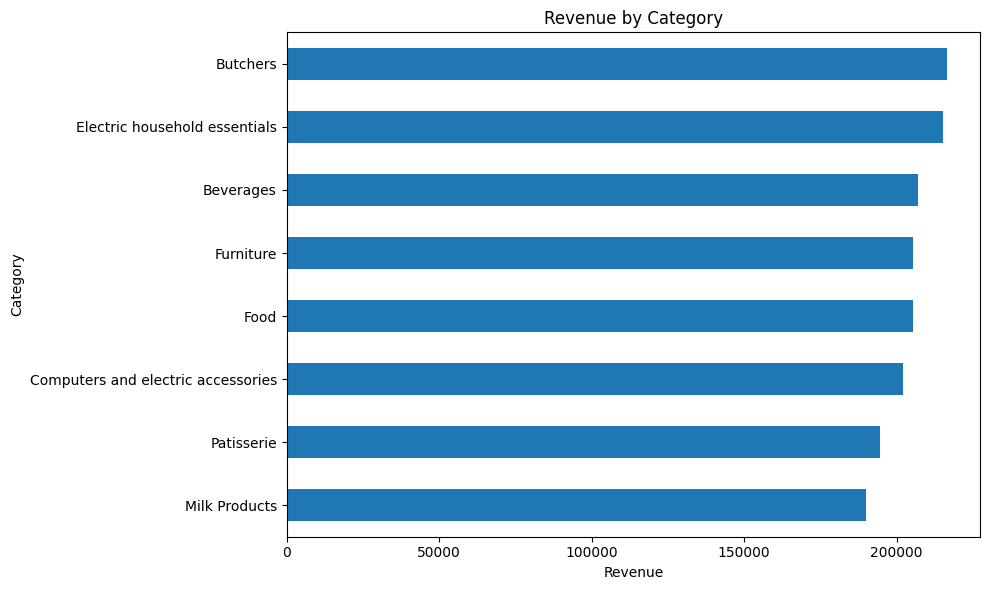

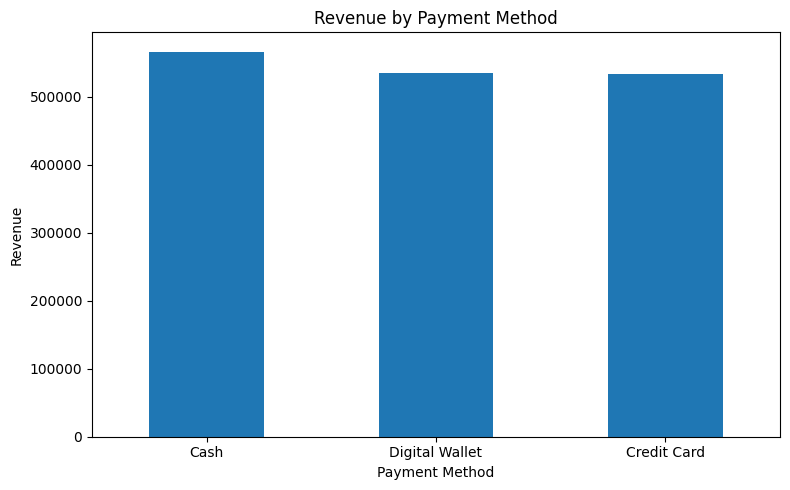

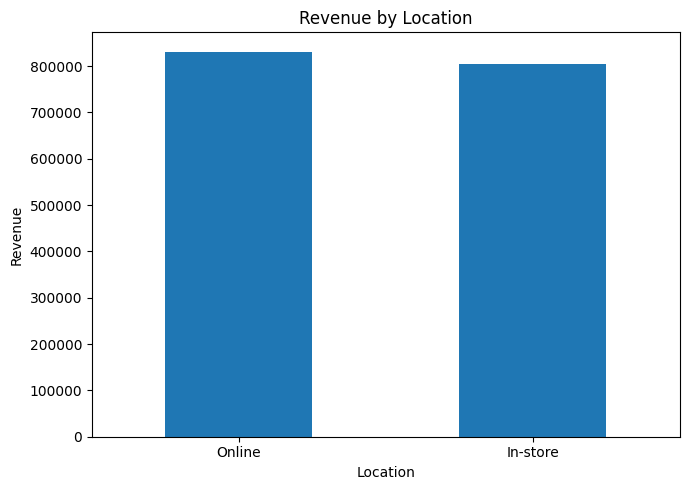

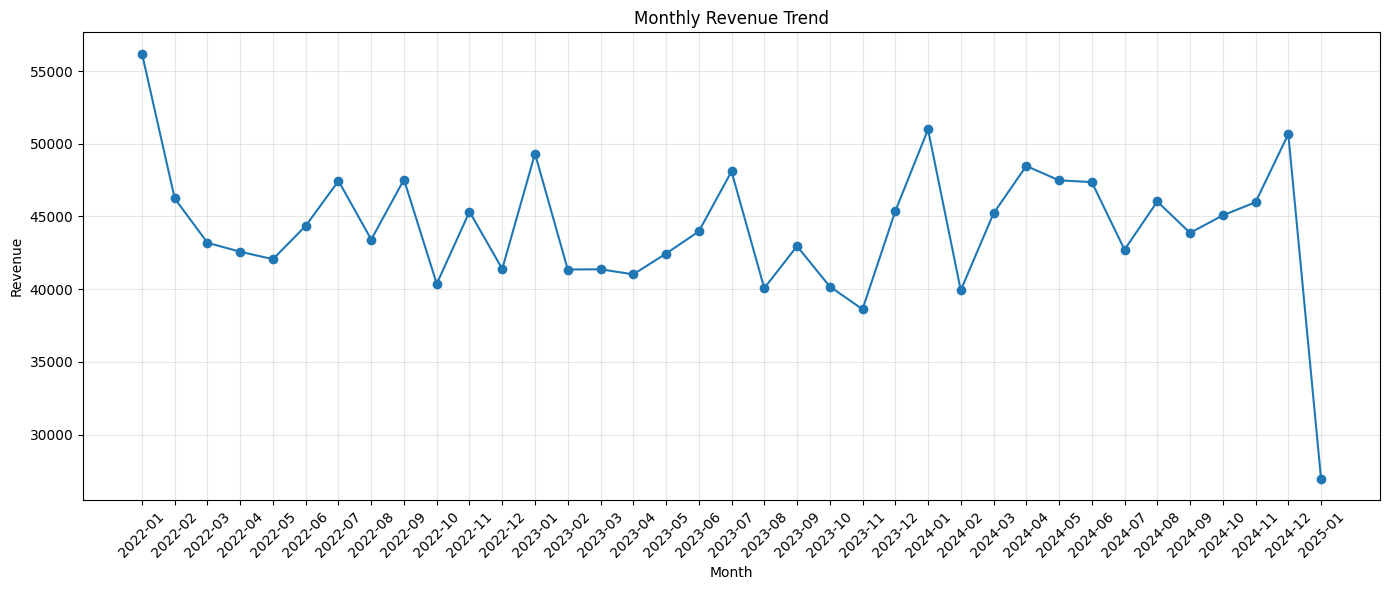


Visualization generation complete.


In [8]:
# STEP 8: Automated Visualizations

import matplotlib.pyplot as plt

print("=" * 70)
print("GENERATING AUTOMATED VISUALIZATIONS")
print("=" * 70)


# --------------------------------------------------
# 1. Revenue by Category
# --------------------------------------------------

plt.figure(figsize=(10, 6))

category_summary["Revenue"].sort_values().plot(
    kind="barh"
)

plt.title("Revenue by Category")
plt.xlabel("Revenue")
plt.ylabel("Category")
plt.tight_layout()
plt.show()


# --------------------------------------------------
# 2. Revenue by Payment Method
# --------------------------------------------------

plt.figure(figsize=(8, 5))

payment_summary["Revenue"].plot(
    kind="bar"
)

plt.title("Revenue by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Revenue")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


# --------------------------------------------------
# 3. Revenue by Location
# --------------------------------------------------

plt.figure(figsize=(7, 5))

location_summary["Revenue"].plot(
    kind="bar"
)

plt.title("Revenue by Location")
plt.xlabel("Location")
plt.ylabel("Revenue")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


# --------------------------------------------------
# 4. Monthly Revenue Trend
# --------------------------------------------------

plt.figure(figsize=(14, 6))

plt.plot(
    monthly_summary["Year_Month"],
    monthly_summary["Revenue"],
    marker="o"
)

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


print("\nVisualization generation complete.")

In [9]:
# STEP 9: Automated Excel Report

from openpyxl import load_workbook
from openpyxl.styles import Font, PatternFill, Alignment
from openpyxl.chart import BarChart, LineChart, Reference
from openpyxl.utils import get_column_letter

report_file = "Retail_Data_Automated_Report.xlsx"

print("=" * 70)
print("GENERATING AUTOMATED EXCEL REPORT")
print("=" * 70)


# --------------------------------------------------
# 1. Create report tables
# --------------------------------------------------

executive_summary = pd.DataFrame({
    "KPI": [
        "Total Revenue",
        "Total Transactions",
        "Unique Customers",
        "Average Transaction Value",
        "Total Quantity Sold"
    ],
    "Value": [
        total_revenue,
        total_transactions,
        unique_customers,
        average_transaction,
        total_quantity
    ]
})


# --------------------------------------------------
# 2. Export all report sections
# --------------------------------------------------

with pd.ExcelWriter(report_file, engine="openpyxl") as writer:

    executive_summary.to_excel(
        writer,
        sheet_name="Executive Summary",
        index=False
    )

    quality_report.to_excel(
        writer,
        sheet_name="Data Quality",
        index=False
    )

    cleaning_actions.to_excel(
        writer,
        sheet_name="Cleaning Actions",
        index=False
    )

    category_summary.reset_index().to_excel(
        writer,
        sheet_name="Category Analysis",
        index=False
    )

    payment_summary.reset_index().to_excel(
        writer,
        sheet_name="Payment Analysis",
        index=False
    )

    location_summary.reset_index().to_excel(
        writer,
        sheet_name="Location Analysis",
        index=False
    )

    customer_summary.reset_index().to_excel(
        writer,
        sheet_name="Customer Analysis",
        index=False
    )

    monthly_summary.to_excel(
        writer,
        sheet_name="Monthly Trend",
        index=False
    )

    clean_df.to_excel(
        writer,
        sheet_name="Clean Data",
        index=False
    )


# --------------------------------------------------
# 3. Apply professional formatting
# --------------------------------------------------

workbook = load_workbook(report_file)

header_fill = PatternFill(
    fill_type="solid",
    fgColor="1F4E78"
)

header_font = Font(
    color="FFFFFF",
    bold=True
)

title_font = Font(
    bold=True,
    size=14
)


for worksheet in workbook.worksheets:

    # Header formatting
    for cell in worksheet[1]:
        cell.fill = header_fill
        cell.font = header_font
        cell.alignment = Alignment(
            horizontal="center"
        )

    # Freeze header row
    worksheet.freeze_panes = "A2"

    # Auto-adjust column widths
    for column_cells in worksheet.columns:

        max_length = 0
        column_letter = get_column_letter(
            column_cells[0].column
        )

        for cell in column_cells:

            if cell.value is not None:
                max_length = max(
                    max_length,
                    len(str(cell.value))
                )

        worksheet.column_dimensions[
            column_letter
        ].width = min(max_length + 2, 40)


# --------------------------------------------------
# 4. Add charts to the report
# --------------------------------------------------

# Category revenue chart
category_ws = workbook["Category Analysis"]

bar_chart = BarChart()
bar_chart.title = "Revenue by Category"
bar_chart.y_axis.title = "Revenue"
bar_chart.x_axis.title = "Category"

data = Reference(
    category_ws,
    min_col=2,
    min_row=1,
    max_row=category_ws.max_row
)

categories = Reference(
    category_ws,
    min_col=1,
    min_row=2,
    max_row=category_ws.max_row
)

bar_chart.add_data(
    data,
    titles_from_data=True
)

bar_chart.set_categories(categories)

category_ws.add_chart(
    bar_chart,
    "G2"
)


# Monthly revenue chart
monthly_ws = workbook["Monthly Trend"]

line_chart = LineChart()
line_chart.title = "Monthly Revenue Trend"
line_chart.y_axis.title = "Revenue"
line_chart.x_axis.title = "Month"

data = Reference(
    monthly_ws,
    min_col=2,
    min_row=1,
    max_row=monthly_ws.max_row
)

categories = Reference(
    monthly_ws,
    min_col=1,
    min_row=2,
    max_row=monthly_ws.max_row
)

line_chart.add_data(
    data,
    titles_from_data=True
)

line_chart.set_categories(categories)

monthly_ws.add_chart(
    line_chart,
    "F2"
)


# --------------------------------------------------
# 5. Save final workbook
# --------------------------------------------------

workbook.save(report_file)

print("\nExcel report generated successfully!")
print("File:", report_file)

GENERATING AUTOMATED EXCEL REPORT

Excel report generated successfully!
File: Retail_Data_Automated_Report.xlsx


In [10]:
# STEP 10A: Export the validated clean dataset

clean_file = "Clean_Retail_Store_Sales.csv"

clean_df.to_csv(
    clean_file,
    index=False
)

print("Clean dataset exported successfully!")
print("File:", clean_file)
print("Rows:", len(clean_df))
print("Columns:", len(clean_df.columns))

Clean dataset exported successfully!
File: Clean_Retail_Store_Sales.csv
Rows: 12575
Columns: 12


In [11]:
# Remove temporary analysis column
if "Year_Month" in clean_df.columns:
    clean_df.drop(columns=["Year_Month"], inplace=True)

# Re-export the final clean dataset
clean_file = "Clean_Retail_Store_Sales.csv"

clean_df.to_csv(
    clean_file,
    index=False
)

print("Final clean dataset exported successfully!")
print("File:", clean_file)
print("Rows:", len(clean_df))
print("Columns:", len(clean_df.columns))
print("\nColumns:")
print(clean_df.columns.tolist())

Final clean dataset exported successfully!
File: Clean_Retail_Store_Sales.csv
Rows: 12575
Columns: 11

Columns:
['Transaction ID', 'Customer ID', 'Category', 'Item', 'Price Per Unit', 'Quantity', 'Total Spent', 'Payment Method', 'Location', 'Transaction Date', 'Discount Applied']


In [12]:
# ============================================================
# TASK 4 - MASTER DATA CLEANING & REPORTING AUTOMATION
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from openpyxl import load_workbook
from openpyxl.styles import Font, PatternFill, Alignment
from openpyxl.chart import BarChart, LineChart, Reference
from openpyxl.utils import get_column_letter


# ============================================================
# 1. CONFIGURATION
# ============================================================

INPUT_FILE = "retail_store_sales.csv"

CLEAN_FILE = "Clean_Retail_Store_Sales.csv"

REPORT_FILE = "Retail_Data_Automated_Report.xlsx"


# ============================================================
# 2. LOAD RAW DATA
# ============================================================

df = pd.read_csv(INPUT_FILE)

print("Raw dataset loaded.")
print("Rows:", len(df))
print("Columns:", len(df.columns))


# ============================================================
# 3. DATA QUALITY AUDIT
# ============================================================

raw_missing = df.isnull().sum().sum()
raw_duplicates = df.duplicated().sum()

print("\nDATA QUALITY AUDIT")
print("------------------")
print("Missing cells:", raw_missing)
print("Duplicate rows:", raw_duplicates)


# ============================================================
# 4. CREATE CLEAN DATASET
# ============================================================

clean_df = df.copy()


# ----- Standardize text columns -----

text_columns = [
    "Transaction ID",
    "Customer ID",
    "Category",
    "Item",
    "Payment Method",
    "Location"
]

for col in text_columns:
    clean_df[col] = (
        clean_df[col]
        .astype("string")
        .str.strip()
    )


# ----- Convert date -----

clean_df["Transaction Date"] = pd.to_datetime(
    clean_df["Transaction Date"],
    errors="coerce"
)


# ----- Discount -----

clean_df["Discount Applied"] = (
    clean_df["Discount Applied"]
    .astype("string")
    .str.strip()
    .fillna("Unknown")
)


# ----- Item -----

clean_df["Item"] = (
    clean_df["Item"]
    .fillna("Unknown Item")
)


# ----- Recover Price -----

price_recoverable = (
    clean_df["Price Per Unit"].isna()
    & clean_df["Quantity"].notna()
    & clean_df["Total Spent"].notna()
    & (clean_df["Quantity"] != 0)
)

clean_df.loc[
    price_recoverable,
    "Price Per Unit"
] = (
    clean_df.loc[
        price_recoverable,
        "Total Spent"
    ]
    /
    clean_df.loc[
        price_recoverable,
        "Quantity"
    ]
)


# ----- Impute Quantity -----

category_median = (
    clean_df
    .groupby("Category")["Quantity"]
    .transform("median")
)

quantity_missing = clean_df["Quantity"].isna()

clean_df.loc[
    quantity_missing,
    "Quantity"
] = category_median[quantity_missing]


# ----- Recalculate Total Spent -----

total_missing = clean_df["Total Spent"].isna()

clean_df.loc[
    total_missing,
    "Total Spent"
] = (
    clean_df.loc[
        total_missing,
        "Price Per Unit"
    ]
    *
    clean_df.loc[
        total_missing,
        "Quantity"
    ]
)


# ----- Numeric conversion -----

numeric_columns = [
    "Price Per Unit",
    "Quantity",
    "Total Spent"
]

for col in numeric_columns:
    clean_df[col] = pd.to_numeric(
        clean_df[col],
        errors="coerce"
    )


# ============================================================
# 5. VALIDATION
# ============================================================

financial_check = (
    clean_df["Total Spent"]
    -
    (
        clean_df["Price Per Unit"]
        *
        clean_df["Quantity"]
    )
).abs()

validation_results = {
    "Missing Cells": int(clean_df.isnull().sum().sum()),
    "Duplicate Rows": int(clean_df.duplicated().sum()),
    "Duplicate Transaction IDs": int(
        clean_df["Transaction ID"].duplicated().sum()
    ),
    "Financial Errors": int(
        (financial_check > 0.01).sum()
    ),
    "Invalid Dates": int(
        clean_df["Transaction Date"].isna().sum()
    ),
    "Negative Prices": int(
        (clean_df["Price Per Unit"] < 0).sum()
    ),
    "Negative Quantities": int(
        (clean_df["Quantity"] < 0).sum()
    ),
    "Negative Total Spent": int(
        (clean_df["Total Spent"] < 0).sum()
    )
}

print("\nVALIDATION RESULTS")
print("------------------")

for check, result in validation_results.items():
    print(f"{check}: {result}")


# ============================================================
# 6. BUSINESS ANALYSIS
# ============================================================

total_revenue = clean_df["Total Spent"].sum()

total_transactions = (
    clean_df["Transaction ID"].nunique()
)

unique_customers = (
    clean_df["Customer ID"].nunique()
)

average_transaction = (
    clean_df["Total Spent"].mean()
)

total_quantity = (
    clean_df["Quantity"].sum()
)


# ----- Category -----

category_summary = (
    clean_df
    .groupby("Category")
    .agg(
        Revenue=("Total Spent", "sum"),
        Transactions=("Transaction ID", "nunique"),
        Quantity_Sold=("Quantity", "sum"),
        Average_Transaction=("Total Spent", "mean")
    )
    .sort_values(
        "Revenue",
        ascending=False
    )
)


# ----- Payment -----

payment_summary = (
    clean_df
    .groupby("Payment Method")
    .agg(
        Revenue=("Total Spent", "sum"),
        Transactions=("Transaction ID", "nunique"),
        Average_Transaction=("Total Spent", "mean")
    )
    .sort_values(
        "Revenue",
        ascending=False
    )
)


# ----- Location -----

location_summary = (
    clean_df
    .groupby("Location")
    .agg(
        Revenue=("Total Spent", "sum"),
        Transactions=("Transaction ID", "nunique"),
        Average_Transaction=("Total Spent", "mean")
    )
    .sort_values(
        "Revenue",
        ascending=False
    )
)


# ----- Customers -----

customer_summary = (
    clean_df
    .groupby("Customer ID")
    .agg(
        Revenue=("Total Spent", "sum"),
        Transactions=("Transaction ID", "nunique"),
        Quantity_Sold=("Quantity", "sum"),
        Average_Transaction=("Total Spent", "mean")
    )
    .sort_values(
        "Revenue",
        ascending=False
    )
)


# ----- Monthly trend -----

monthly_summary = (
    clean_df
    .assign(
        Year_Month=clean_df["Transaction Date"]
        .dt.to_period("M")
        .astype(str)
    )
    .groupby("Year_Month")
    .agg(
        Revenue=("Total Spent", "sum"),
        Transactions=("Transaction ID", "nunique"),
        Quantity_Sold=("Quantity", "sum")
    )
    .reset_index()
)


# ============================================================
# 7. EXECUTIVE SUMMARY
# ============================================================

executive_summary = pd.DataFrame({
    "KPI": [
        "Total Revenue",
        "Total Transactions",
        "Unique Customers",
        "Average Transaction Value",
        "Total Quantity Sold"
    ],
    "Value": [
        total_revenue,
        total_transactions,
        unique_customers,
        average_transaction,
        total_quantity
    ]
})


# ============================================================
# 8. CLEANING SUMMARY
# ============================================================

cleaning_actions = pd.DataFrame({
    "Column / Area": [
        "Item",
        "Price Per Unit",
        "Quantity",
        "Total Spent",
        "Discount Applied",
        "Transaction Date",
        "Duplicate Records"
    ],

    "Action Taken": [
        "Missing values replaced with 'Unknown Item'",
        "Recovered using Total Spent / Quantity",
        "Missing values imputed using category median",
        "Recalculated using Price × Quantity",
        "Missing values replaced with 'Unknown'",
        "Converted to datetime",
        "Validated; no duplicates removed"
    ]
})


# ============================================================
# 9. EXPORT CLEAN DATA
# ============================================================

clean_df.to_csv(
    CLEAN_FILE,
    index=False
)


# ============================================================
# 10. GENERATE EXCEL REPORT
# ============================================================

with pd.ExcelWriter(
    REPORT_FILE,
    engine="openpyxl"
) as writer:

    executive_summary.to_excel(
        writer,
        sheet_name="Executive Summary",
        index=False
    )

    quality_data = pd.DataFrame({
        "Metric": [
            "Rows",
            "Columns",
            "Missing Cells",
            "Completeness %",
            "Duplicate Rows"
        ],
        "Before Cleaning": [
            len(df),
            len(df.columns),
            raw_missing,
            round(
                (1 - raw_missing /
                 (len(df) * len(df.columns))) * 100,
                2
            ),
            raw_duplicates
        ],
        "After Cleaning": [
            len(clean_df),
            len(clean_df.columns),
            clean_df.isnull().sum().sum(),
            100.0,
            clean_df.duplicated().sum()
        ]
    })

    quality_data.to_excel(
        writer,
        sheet_name="Data Quality",
        index=False
    )

    cleaning_actions.to_excel(
        writer,
        sheet_name="Cleaning Actions",
        index=False
    )

    category_summary.reset_index().to_excel(
        writer,
        sheet_name="Category Analysis",
        index=False
    )

    payment_summary.reset_index().to_excel(
        writer,
        sheet_name="Payment Analysis",
        index=False
    )

    location_summary.reset_index().to_excel(
        writer,
        sheet_name="Location Analysis",
        index=False
    )

    customer_summary.reset_index().to_excel(
        writer,
        sheet_name="Customer Analysis",
        index=False
    )

    monthly_summary.to_excel(
        writer,
        sheet_name="Monthly Trend",
        index=False
    )


# ============================================================
# 11. FORMAT EXCEL REPORT
# ============================================================

workbook = load_workbook(REPORT_FILE)

header_fill = PatternFill(
    fill_type="solid",
    fgColor="1F4E78"
)

header_font = Font(
    color="FFFFFF",
    bold=True
)


for worksheet in workbook.worksheets:

    for cell in worksheet[1]:
        cell.fill = header_fill
        cell.font = header_font
        cell.alignment = Alignment(
            horizontal="center"
        )

    worksheet.freeze_panes = "A2"

    for column_cells in worksheet.columns:

        max_length = 0

        column_letter = get_column_letter(
            column_cells[0].column
        )

        for cell in column_cells:

            if cell.value is not None:
                max_length = max(
                    max_length,
                    len(str(cell.value))
                )

        worksheet.column_dimensions[
            column_letter
        ].width = min(
            max_length + 2,
            40
        )


# ============================================================
# 12. ADD CATEGORY CHART
# ============================================================

category_ws = workbook["Category Analysis"]

bar_chart = BarChart()

bar_chart.title = "Revenue by Category"
bar_chart.y_axis.title = "Revenue"
bar_chart.x_axis.title = "Category"

data = Reference(
    category_ws,
    min_col=2,
    min_row=1,
    max_row=category_ws.max_row
)

categories = Reference(
    category_ws,
    min_col=1,
    min_row=2,
    max_row=category_ws.max_row
)

bar_chart.add_data(
    data,
    titles_from_data=True
)

bar_chart.set_categories(categories)

category_ws.add_chart(
    bar_chart,
    "G2"
)


# ============================================================
# 13. ADD MONTHLY TREND CHART
# ============================================================

monthly_ws = workbook["Monthly Trend"]

line_chart = LineChart()

line_chart.title = "Monthly Revenue Trend"
line_chart.y_axis.title = "Revenue"
line_chart.x_axis.title = "Month"

data = Reference(
    monthly_ws,
    min_col=2,
    min_row=1,
    max_row=monthly_ws.max_row
)

categories = Reference(
    monthly_ws,
    min_col=1,
    min_row=2,
    max_row=monthly_ws.max_row
)

line_chart.add_data(
    data,
    titles_from_data=True
)

line_chart.set_categories(categories)

monthly_ws.add_chart(
    line_chart,
    "F2"
)


# ============================================================
# 14. SAVE REPORT
# ============================================================

workbook.save(REPORT_FILE)


# ============================================================
# 15. FINAL STATUS
# ============================================================

print("\n" + "=" * 70)
print("AUTOMATION COMPLETED SUCCESSFULLY")
print("=" * 70)

print("Clean dataset:", CLEAN_FILE)
print("Excel report:", REPORT_FILE)

print("\nValidation:")
for check, result in validation_results.items():
    print(f"{check}: {result}")

Raw dataset loaded.
Rows: 12575
Columns: 11

DATA QUALITY AUDIT
------------------
Missing cells: 7229
Duplicate rows: 0

VALIDATION RESULTS
------------------
Missing Cells: 0
Duplicate Rows: 0
Duplicate Transaction IDs: 0
Financial Errors: 0
Invalid Dates: 0
Negative Prices: 0
Negative Quantities: 0
Negative Total Spent: 0

AUTOMATION COMPLETED SUCCESSFULLY
Clean dataset: Clean_Retail_Store_Sales.csv
Excel report: Retail_Data_Automated_Report.xlsx

Validation:
Missing Cells: 0
Duplicate Rows: 0
Duplicate Transaction IDs: 0
Financial Errors: 0
Invalid Dates: 0
Negative Prices: 0
Negative Quantities: 0
Negative Total Spent: 0


In [13]:
import os

project_files = [
    "retail_store_sales.csv",
    "Clean_Retail_Store_Sales.csv",
    "Retail_Data_Automated_Report.xlsx"
]

for file in project_files:
    print(file, "->", "FOUND" if os.path.exists(file) else "MISSING")

retail_store_sales.csv -> FOUND
Clean_Retail_Store_Sales.csv -> FOUND
Retail_Data_Automated_Report.xlsx -> FOUND


In [14]:
# Create the final Python automation file

script_code = r'''
# TASK 4 - DATA CLEANING & REPORTING AUTOMATION

import pandas as pd
import numpy as np
from openpyxl import load_workbook
from openpyxl.styles import Font, PatternFill, Alignment
from openpyxl.chart import BarChart, LineChart, Reference
from openpyxl.utils import get_column_letter

INPUT_FILE = "retail_store_sales.csv"
CLEAN_FILE = "Clean_Retail_Store_Sales.csv"
REPORT_FILE = "Retail_Data_Automated_Report.xlsx"

# Load raw data
df = pd.read_csv(INPUT_FILE)

# Create clean copy
clean_df = df.copy()

# Standardize text
text_columns = [
    "Transaction ID",
    "Customer ID",
    "Category",
    "Item",
    "Payment Method",
    "Location"
]

for col in text_columns:
    clean_df[col] = clean_df[col].astype("string").str.strip()

# Convert date
clean_df["Transaction Date"] = pd.to_datetime(
    clean_df["Transaction Date"],
    errors="coerce"
)

# Handle discount
clean_df["Discount Applied"] = (
    clean_df["Discount Applied"]
    .astype("string")
    .str.strip()
    .fillna("Unknown")
)

# Handle missing items
clean_df["Item"] = clean_df["Item"].fillna("Unknown Item")

# Recover missing prices
price_recoverable = (
    clean_df["Price Per Unit"].isna()
    & clean_df["Quantity"].notna()
    & clean_df["Total Spent"].notna()
    & (clean_df["Quantity"] != 0)
)

clean_df.loc[price_recoverable, "Price Per Unit"] = (
    clean_df.loc[price_recoverable, "Total Spent"]
    / clean_df.loc[price_recoverable, "Quantity"]
)

# Impute missing quantity using category median
category_median = (
    clean_df.groupby("Category")["Quantity"].transform("median")
)

quantity_missing = clean_df["Quantity"].isna()

clean_df.loc[quantity_missing, "Quantity"] = (
    category_median[quantity_missing]
)

# Recalculate missing total spent
total_missing = clean_df["Total Spent"].isna()

clean_df.loc[total_missing, "Total Spent"] = (
    clean_df.loc[total_missing, "Price Per Unit"]
    * clean_df.loc[total_missing, "Quantity"]
)

# Convert numeric columns
for col in ["Price Per Unit", "Quantity", "Total Spent"]:
    clean_df[col] = pd.to_numeric(
        clean_df[col],
        errors="coerce"
    )

# Validation
financial_difference = (
    clean_df["Total Spent"]
    - clean_df["Price Per Unit"] * clean_df["Quantity"]
).abs()

print("VALIDATION RESULTS")
print("------------------")
print("Missing Cells:", clean_df.isnull().sum().sum())
print("Duplicate Rows:", clean_df.duplicated().sum())
print(
    "Duplicate Transaction IDs:",
    clean_df["Transaction ID"].duplicated().sum()
)
print(
    "Financial Errors:",
    (financial_difference > 0.01).sum()
)
print(
    "Invalid Dates:",
    clean_df["Transaction Date"].isna().sum()
)

# Business analysis
total_revenue = clean_df["Total Spent"].sum()
total_transactions = clean_df["Transaction ID"].nunique()
unique_customers = clean_df["Customer ID"].nunique()
average_transaction = clean_df["Total Spent"].mean()
total_quantity = clean_df["Quantity"].sum()

category_summary = (
    clean_df.groupby("Category")
    .agg(
        Revenue=("Total Spent", "sum"),
        Transactions=("Transaction ID", "nunique"),
        Quantity_Sold=("Quantity", "sum"),
        Average_Transaction=("Total Spent", "mean")
    )
    .sort_values("Revenue", ascending=False)
)

payment_summary = (
    clean_df.groupby("Payment Method")
    .agg(
        Revenue=("Total Spent", "sum"),
        Transactions=("Transaction ID", "nunique"),
        Average_Transaction=("Total Spent", "mean")
    )
    .sort_values("Revenue", ascending=False)
)

location_summary = (
    clean_df.groupby("Location")
    .agg(
        Revenue=("Total Spent", "sum"),
        Transactions=("Transaction ID", "nunique"),
        Average_Transaction=("Total Spent", "mean")
    )
    .sort_values("Revenue", ascending=False)
)

monthly_summary = (
    clean_df.assign(
        Year_Month=clean_df["Transaction Date"]
        .dt.to_period("M")
        .astype(str)
    )
    .groupby("Year_Month")
    .agg(
        Revenue=("Total Spent", "sum"),
        Transactions=("Transaction ID", "nunique"),
        Quantity_Sold=("Quantity", "sum")
    )
    .reset_index()
)

# Executive summary
executive_summary = pd.DataFrame({
    "KPI": [
        "Total Revenue",
        "Total Transactions",
        "Unique Customers",
        "Average Transaction Value",
        "Total Quantity Sold"
    ],
    "Value": [
        total_revenue,
        total_transactions,
        unique_customers,
        average_transaction,
        total_quantity
    ]
})

# Export clean data
clean_df.to_csv(CLEAN_FILE, index=False)

# Create Excel report
with pd.ExcelWriter(REPORT_FILE, engine="openpyxl") as writer:

    executive_summary.to_excel(
        writer,
        sheet_name="Executive Summary",
        index=False
    )

    category_summary.reset_index().to_excel(
        writer,
        sheet_name="Category Analysis",
        index=False
    )

    payment_summary.reset_index().to_excel(
        writer,
        sheet_name="Payment Analysis",
        index=False
    )

    location_summary.reset_index().to_excel(
        writer,
        sheet_name="Location Analysis",
        index=False
    )

    monthly_summary.to_excel(
        writer,
        sheet_name="Monthly Trend",
        index=False
    )

    clean_df.to_excel(
        writer,
        sheet_name="Clean Data",
        index=False
    )

# Format workbook
workbook = load_workbook(REPORT_FILE)

header_fill = PatternFill(
    fill_type="solid",
    fgColor="1F4E78"
)

header_font = Font(
    color="FFFFFF",
    bold=True
)

for worksheet in workbook.worksheets:

    for cell in worksheet[1]:
        cell.fill = header_fill
        cell.font = header_font
        cell.alignment = Alignment(
            horizontal="center"
        )

    worksheet.freeze_panes = "A2"

    for column_cells in worksheet.columns:

        max_length = 0
        column_letter = get_column_letter(
            column_cells[0].column
        )

        for cell in column_cells:
            if cell.value is not None:
                max_length = max(
                    max_length,
                    len(str(cell.value))
                )

        worksheet.column_dimensions[
            column_letter
        ].width = min(max_length + 2, 40)

# Category chart
category_ws = workbook["Category Analysis"]

bar_chart = BarChart()
bar_chart.title = "Revenue by Category"
bar_chart.y_axis.title = "Revenue"
bar_chart.x_axis.title = "Category"

data = Reference(
    category_ws,
    min_col=2,
    min_row=1,
    max_row=category_ws.max_row
)

categories = Reference(
    category_ws,
    min_col=1,
    min_row=2,
    max_row=category_ws.max_row
)

bar_chart.add_data(data, titles_from_data=True)
bar_chart.set_categories(categories)

category_ws.add_chart(bar_chart, "G2")

# Monthly chart
monthly_ws = workbook["Monthly Trend"]

line_chart = LineChart()
line_chart.title = "Monthly Revenue Trend"
line_chart.y_axis.title = "Revenue"
line_chart.x_axis.title = "Month"

data = Reference(
    monthly_ws,
    min_col=2,
    min_row=1,
    max_row=monthly_ws.max_row
)

categories = Reference(
    monthly_ws,
    min_col=1,
    min_row=2,
    max_row=monthly_ws.max_row
)

line_chart.add_data(data, titles_from_data=True)
line_chart.set_categories(categories)

monthly_ws.add_chart(line_chart, "F2")

workbook.save(REPORT_FILE)

print("\nAUTOMATION COMPLETED")
print("Clean dataset:", CLEAN_FILE)
print("Excel report:", REPORT_FILE)
'''

with open("task4_automation.py", "w", encoding="utf-8") as f:
    f.write(script_code)

print("task4_automation.py created successfully!")

task4_automation.py created successfully!


In [15]:
import os

print(
    "task4_automation.py ->",
    "FOUND" if os.path.exists("task4_automation.py")
    else "MISSING"
)

task4_automation.py -> FOUND


# Final Automated Workflow

The complete cleaning and reporting process is also implemented as a reusable Python automation script.

The automation:

1. Loads the raw retail sales dataset.
2. Cleans missing and inconsistent values.
3. Handles duplicate records.
4. Validates the cleaned data.
5. Creates audit/provenance flags.
6. Generates the cleaned CSV dataset.
7. Generates the audit flags CSV.
8. Generates the automated Excel report.

The reusable script is:

`task4_automation_final_v2.py`


In [17]:
# Run the reusable automation script
!python task4_automation_final_v2.py

INFO | Loaded 12575 rows x 11 columns
INFO | Standardise text                    12575 rows | Stripped whitespace and standardised null-like tokens
INFO | Remove duplicate rows                   0 rows | Exact duplicate rows dropped
INFO | Remove duplicate Transaction IDs        0 rows | Kept first occurrence
INFO | Parse dates / numerics                  0 rows | Invalid dates become NaT
INFO | Discount Applied                     4199 rows | Missing flags labelled Unknown; no assumption made
INFO | Recover Item from price               604 rows | Only unique Category + Price mappings used
INFO | Unknown Item label                    609 rows | Could not be safely recovered
INFO | Recover Price from item                 0 rows | Used the modal known price for the item
INFO | Recover Price from Total/Qty          609 rows | Total Spent / Quantity
INFO | Recover Quantity from Total/Price       0 rows | Exact recovery where mathematically determined
INFO | Impute Quantity (median)       